# №2 (5 баллов)
[Скачайте файл с данными о публикациях на сайте Хабрахабр](https://cloud.mail.ru/public/3ViL/q5xSM1TH2).

1. Изучите датасет, попробуйте понять какой столбец за что отвечает.

In [14]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sb

def print_col_dtype(df):
    print(pd.DataFrame({
    'Столбец': df.columns,
    'Тип_данных': [str(dtype) for dtype in df.dtypes]
    }).to_string(index=False))
    print("\n\n")

df = pd.read_csv('howpop_train.csv')
print("Названия столбцов и типы данных:")
print_col_dtype(df)

Названия столбцов и типы данных:
         Столбец Тип_данных
             url     object
          domain     object
         post_id      int64
       published     object
          author     object
            flow     object
         polling     object
     content_len     object
           title     object
        comments      int64
            favs      int64
           views     object
      votes_plus     object
     votes_minus     object
   views_lognorm     object
    favs_lognorm     object
comments_lognorm     object
     Unnamed: 17     object
     Unnamed: 18    float64





C:\Users\user\AppData\Local\Temp\ipykernel_22376\2141990845.py:13: DtypeWarning: Columns (6,7,11,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('howpop_train.csv')


2. Удалите столбцы, названия которых заканчиваются на _lognorm. Выберите их с помощью `filter()` и удалите `drop`-ом:
```
df.drop(
    filter(lambda c: c.endswith("_lognorm"), df.columns),
    axis=1,         # axis = 1: столбцы
    inplace=True,
) # избавляет от необходимости сохранять датасет
```

In [15]:
df.drop(
    filter(lambda c: c.endswith("_lognorm"), df.columns),
    axis=1,
    inplace=True)

print_col_dtype(df)
print("Видим что столбцы заканч. на _lognorm удалены.")

    Столбец Тип_данных
        url     object
     domain     object
    post_id      int64
  published     object
     author     object
       flow     object
    polling     object
content_len     object
      title     object
   comments      int64
       favs      int64
      views     object
 votes_plus     object
votes_minus     object
Unnamed: 17     object
Unnamed: 18    float64



Видим что столбцы заканч. на _lognorm удалены.


3. Столбец `published` (время публикации) содержит строки. Чтобы работать с этими данными как с датой/временем публикации, приведите их к типу `datetime`:
`df["published"] = pd.to_datetime(df.published, yearfirst=True)`

In [16]:
df["published"] = pd.to_datetime(df.published, yearfirst=True)
print("\nТип данных после преобразования: ")
print(f'"published": {df["published"].dtype}')


Тип данных после преобразования: 
"published": datetime64[ns]


4. Создайте несколько столбцов на основе данных о времени публикации:

```
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]

df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]
```


In [17]:
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]

df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]

print_col_dtype(df)

    Столбец     Тип_данных
        url         object
     domain         object
    post_id          int64
  published datetime64[ns]
     author         object
       flow         object
    polling         object
content_len         object
      title         object
   comments          int64
       favs          int64
      views         object
 votes_plus         object
votes_minus         object
Unnamed: 17         object
Unnamed: 18        float64
       year          int64
      month          int64
  dayofweek          int64
       hour          int64





5. Используя Seaborn, постройте визуализацию и покажите в каком месяце (и какого года) было больше всего публикаций.

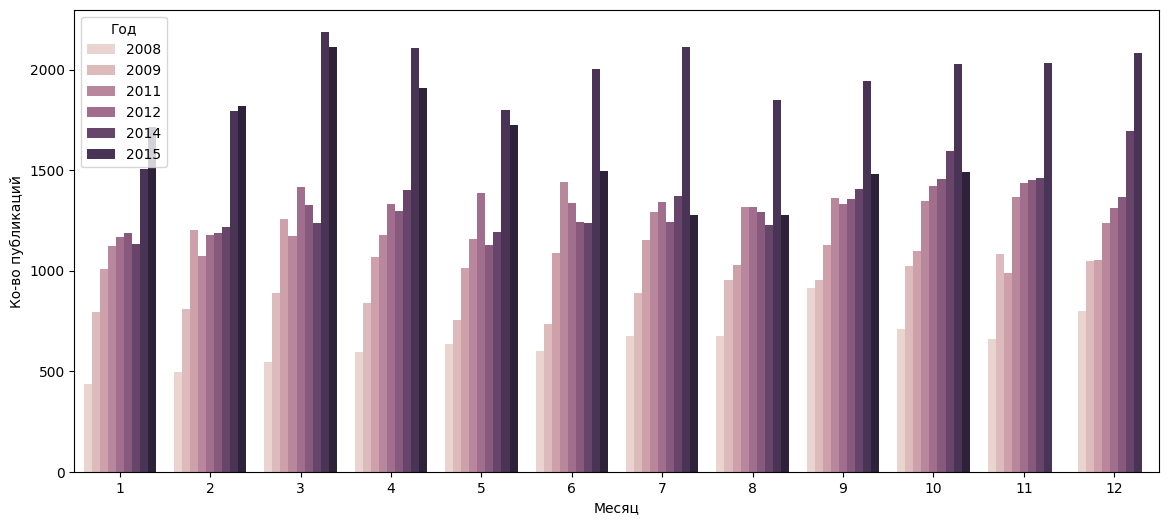

In [18]:
monthly_counts = df.groupby(['year', 'month']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))
sb.barplot(data=monthly_counts, x='month', y='count', hue='year')
plt.xlabel('Месяц')
plt.ylabel('Ко-во публикаций')
plt.legend(title='Год')
plt.show()

6. Используя Seaborn, постройте график зависимости числа публикаций от дня недели, используя параметр hue.

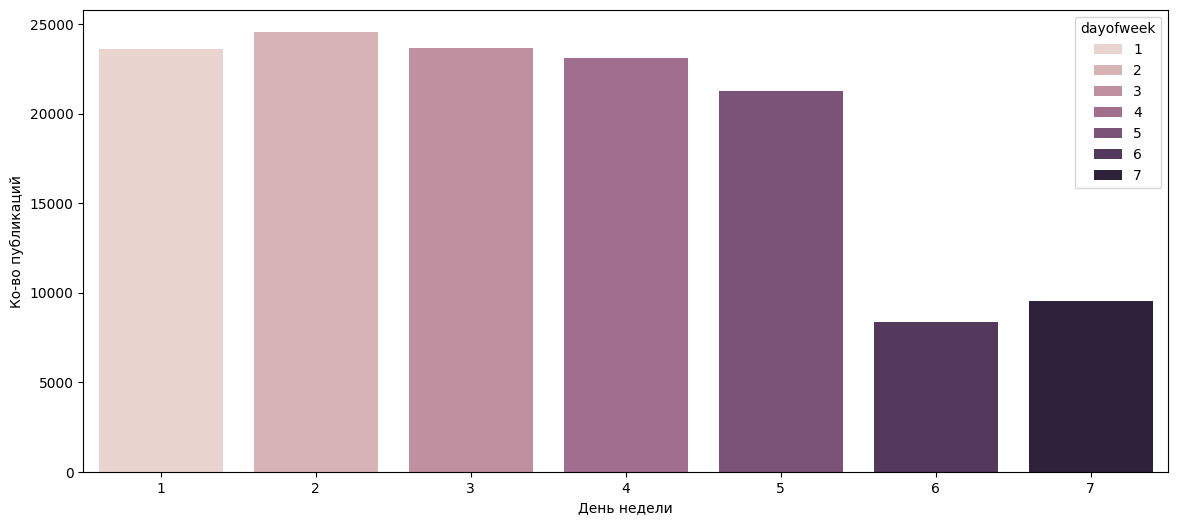

In [19]:
daily_counts = df.groupby('dayofweek').size().reset_index(name='count')

plt.figure(figsize=(14, 6))
sb.barplot(data=daily_counts, x='dayofweek', y='count', hue='dayofweek')
plt.xlabel('День недели')
plt.ylabel('Ко-во публикаций')
plt.show()

7. Используя Seaborn, проведите визуальный анализ и отметьте верные утверждения про данный датасет:
- ✔ Больше всего просмотров набирают статьи, опубликованные в 12 часов дня 
(по графику видно что утверждение верно)
- **X** У опубликованных в 10 утра постов больше всего комментариев
- **X** Больше всего просмотров набирают статьи, опубликованные в 6 часов утра
- **X** Максимальное число комментариев на гиктаймсе набрала статья, опубликованная в 9 часов вечера
- **X** На хабре дневные статьи комментируют чаще, чем вечерние

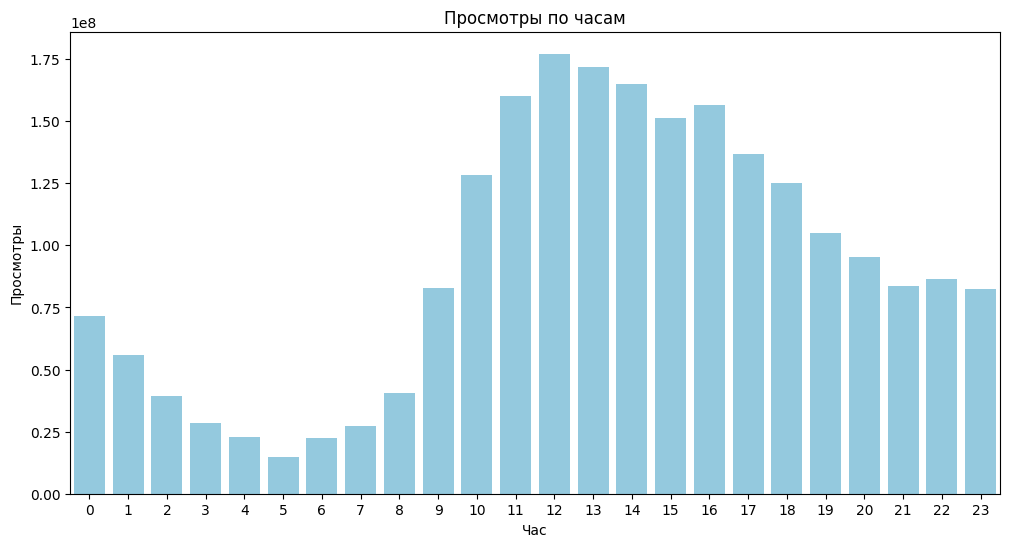

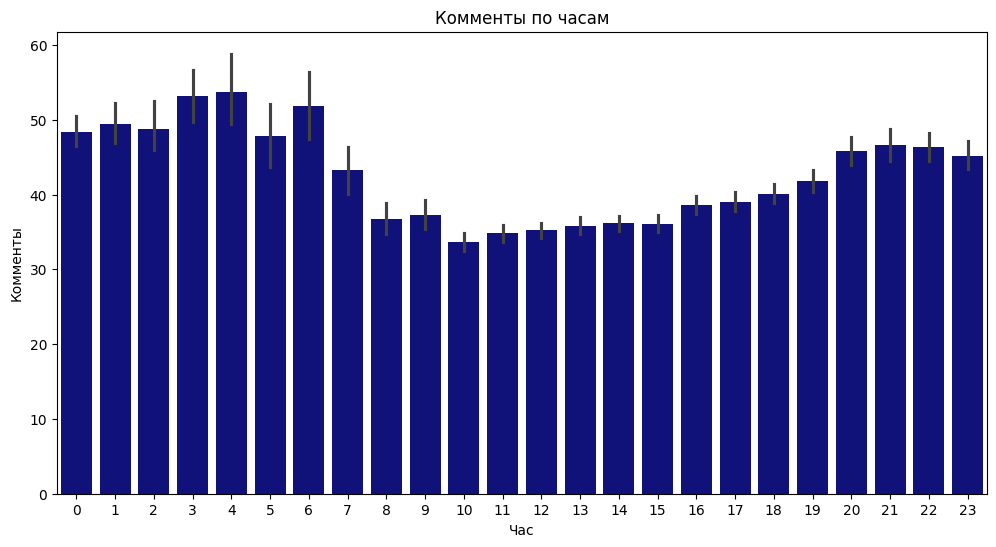

Пост с максимальным количеством комментариев:
post_id: 123157
domain: geektimes.ru
comments: 2266
hour: 2


In [28]:
# просмотры по часам
df["views"] = pd.to_numeric(df["views"], errors="coerce")
# на всякий случай конвертим в числа
hourly_views = df.groupby('hour')['views'].sum().reset_index()
plt.figure(figsize=(12, 6))
sb.barplot(data=hourly_views, x='hour', y='views', color='skyblue')
plt.title("Просмотры по часам")
plt.xlabel("Час")
plt.ylabel("Просмотры")
plt.show()

# комменты по часам
plt.figure(figsize=(12, 6))
sb.barplot(data=df, x='hour', y='comments', color='darkblue')
plt.title('Комменты по часам')
plt.xlabel('Час')
plt.ylabel('Комменты')
plt.show()

# ищем пост с наиб. числом комментов на гиктаймс
geek_comments = df[df['domain'] == 'geektimes.ru']
max_comments_post = geek_comments.loc[geek_comments['comments'].idxmax()]
print(f"Пост с максимальным количеством комментариев:")
print(f"post_id: {max_comments_post['post_id']}")
print(f"domain: {max_comments_post['domain']}")
print(f"comments: {max_comments_post['comments']}")
print(f"hour: {max_comments_post['hour']}")


8. Используя Seaborn, проведите визуальный анализ и определите кого из топ-20 авторов чаще всего минусуют?

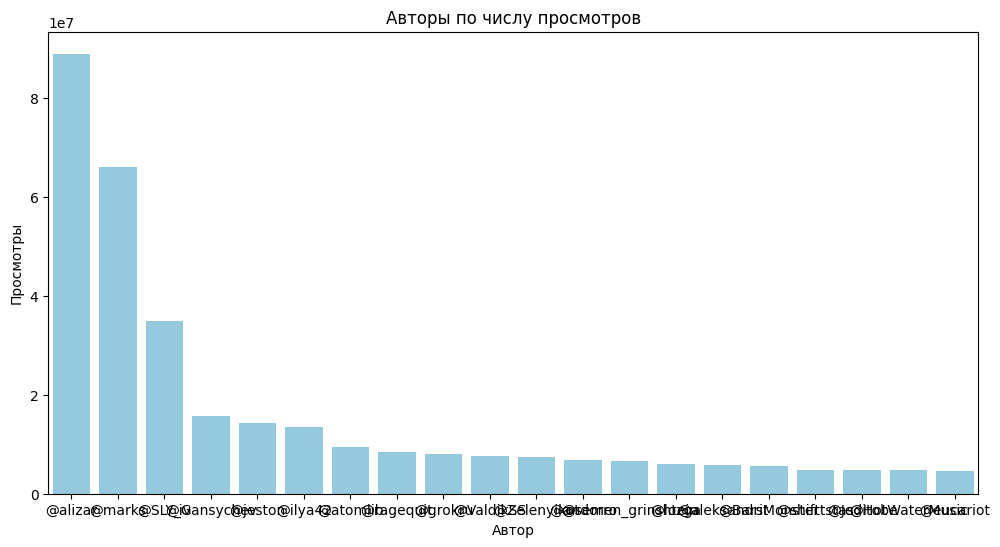

Топовые авторы ник - просмотры:
                  author       views
9434             @alizar  88970145.0
15851             @marks  65945478.0
6666              @SLY_G  34859043.0
14212        @ivansychev  15699008.0
14345            @jeston  14365117.0
13931            @ilya42  13415226.0
10139           @atomlib   9508683.0
18130          @ragequit   8423500.0
13351            @grokru   7944918.0
8033           @ValdikSS   7575506.0
8727         @Zelenyikot   7390100.0
9614            @andorro   6807355.0
18857  @semen_grinshtein   6633858.0
15572             @lozga   6025799.0
9187        @aleksandrit   5725020.0
1299        @BarsMonster   5552829.0
19106        @shifttstas   4856107.0
3980           @Jeditobe   4824471.0
3568      @HotWaterMusic   4674400.0
12496          @eucariot   4505510.0


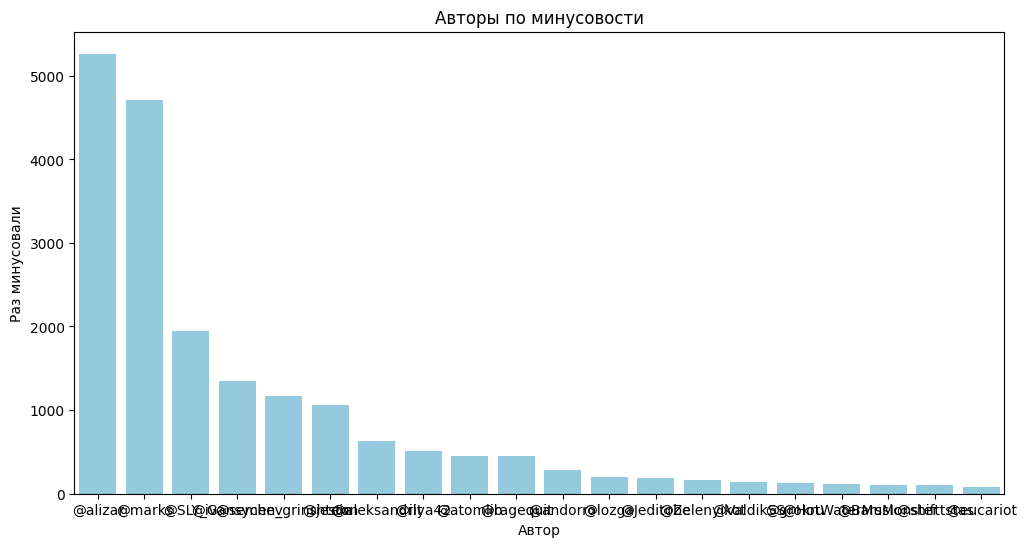

Чаще всего минусют следующих 5 авторов:
                  author  votes_minus_count
9434             @alizar               5265
15851             @marks               4710
6666              @SLY_G               1940
14212        @ivansychev               1351
18857  @semen_grinshtein               1172


In [72]:
# пусть топовость определяется числом просмотров на постах
df = df[df['author'].str.startswith('@', na=False)]

authors_top = df.groupby('author')[['views','votes_minus']].sum().reset_index().sort_values(by='views', ascending=False)
authors_top = authors_top.head(20)
plt.figure(figsize=(12, 6))
sb.barplot(data=authors_top, x='author', y='views', color='skyblue')
plt.title("Авторы по числу просмотров")
plt.xlabel("Автор")
plt.ylabel("Просмотры")
plt.show()
print("Топовые авторы ник - просмотры:")
print(authors_top[['author', 'views']])


authors_top['votes_minus_count'] = authors_top['votes_minus'].apply(lambda x: len(x.split(',')) if isinstance(x, str) and x else 0)
authors_top_minus = authors_top.sort_values(by='votes_minus_count', ascending=False)
plt.figure(figsize=(12, 6))
sb.barplot(data=authors_top_minus, x='author', y='votes_minus_count', color='skyblue')
plt.title("Авторы по минусовости")
plt.xlabel("Автор")
plt.ylabel("Раз минусовали")
plt.show()
print("Чаще всего минусют следующих 5 авторов:")
print(authors_top_minus[['author', 'votes_minus_count']].head(5))


9. Используя Seaborn, сравните субботы и понедельники. Правда ли, что по субботам авторы пишут в основном днём, а по понедельникам — в основном вечером?
- в субботу чаще пишут днём - да
- в понедельник тоже чаще пишут днём - (ответ нет)

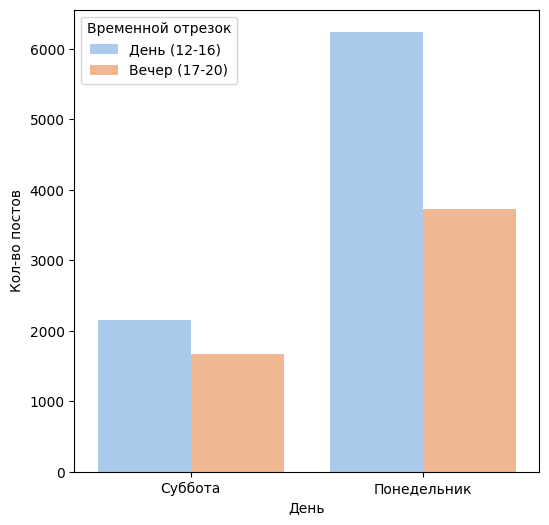

In [83]:
# пусть день с 12 до 16
# пусть вечер с 17 до 20

daytime_hrs = range(12, 17)
evening_hrs = range(17, 21)

saturday_daytime = df[(df['dayofweek'] == 6) & (df['hour'].isin(daytime_hrs))].shape[0]
saturday_evening = df[(df['dayofweek'] == 6) & (df['hour'].isin(evening_hrs))].shape[0]
monday_daytime = df[(df['dayofweek'] == 1) & (df['hour'].isin(daytime_hrs))].shape[0]
monday_evening = df[(df['dayofweek'] == 1) & (df['hour'].isin(evening_hrs))].shape[0]

combining_for_plot = pd.DataFrame({
    'День': ['Суббота', 'Суббота', 'Понедельник', 'Понедельник'],
    'Временной отрезок': ['День (12-16)', 'Вечер (17-20)', 'День (12-16)', 'Вечер (17-20)'],
    'Кол-во постов': [saturday_daytime, saturday_evening, monday_daytime, monday_evening]
})

plt.figure(figsize=(6, 6))
sb.barplot(x='День', y='Кол-во постов', hue='Временной отрезок', data=combining_for_plot, palette='pastel')
plt.show()